In [1]:
import nsbi_common_utils
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt

In [2]:
BASE_PATH = "./data_nsbi_tutorial/"

In [3]:
nodes = [0, 5, 10]

In [4]:
signals = {
    f"signal_{n:g}": pd.read_parquet(f"{BASE_PATH}/signal_{n:g}.parquet") for n in nodes
}
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

In [5]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

In [6]:
numerator_hypothesis = signals["signal_0"].astype('float32').copy()
denominator_hypothesis = background.astype('float32').copy()

In [7]:
numerator_hypothesis["weights"] = numerator_hypothesis['weight']
numerator_hypothesis["weights_normed"] = numerator_hypothesis['weight'] / numerator_hypothesis['weight'].sum()
numerator_hypothesis["train_labels"] = 1.0

denominator_hypothesis["weights"] = denominator_hypothesis['weight']
denominator_hypothesis["weights_normed"] = denominator_hypothesis['weight'] / denominator_hypothesis['weight'].sum()
denominator_hypothesis["train_labels"] = 0.0

In [8]:
training_dataframe = pd.concat([numerator_hypothesis, denominator_hypothesis], ignore_index=True)

In [ ]:
# !pip install lightning
# !pip install onnx
# !pip install onnxruntime
# !pip install onnxscript

In [10]:
from nsbi_common_utils.training import density_ratio_trainer

trainer = density_ratio_trainer(
    dataset=training_dataframe,
    weights=training_dataframe["weights_normed"],
    training_labels=training_dataframe["train_labels"],
    features=training_features,
    features_scaling=training_features,
    sample_name=["signal_0", "background"],
    output_name="sig/bkg",
    path_to_figures="plots_sig0vsBkg/",
    path_to_models="models_sig0vsBkg/",
)

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:10: FutureWarning: ``set_style`` is deprecated: Naming convention is changing to match mpl. Use ``mplhep.style.use()``.
  hep.set_style("ATLAS")


In [11]:
import sys, nsbi_common_utils.training
m = sys.modules['nsbi_common_utils.training']
print("file:", m.__file__)
print("has utils attr:", hasattr(m, 'utils'))
print("dir:", [x for x in dir(m) if not x.startswith('_')])
print("utils in sys.modules:", 'nsbi_common_utils.training.utils' in sys.modules)


file: /Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/training/__init__.py
has utils attr: True
dir: ['convert_logLR_to_score', 'convert_score_to_ratio', 'convert_torch_to_onnx', 'density_ratio_trainer', 'load_trained_model', 'neural_ratio_estimation', 'nsbi_common_utils', 'predict_with_model', 'predict_with_onnx', 'preselection_network_trainer', 'preselection_training', 'save_model', 'utils']
utils in sys.modules: True


In [12]:
trainer.train(
    hidden_layers=3,
    neurons=1024,
    number_of_epochs=1,
    batch_size=30000,
    learning_rate=1e-3,
    scalerType="StandardScaler",
    ensemble_index=0,
    verbose=1,
    holdout_split=0.25, # validation
    validation_split=0.2,
    callback_patience=10,
    num_workers=4,
    load_trained_models=True
)

2026-05-13 13:34:45 | INFO | Training Logs | Reading saved models from models_sig0vsBkg/
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
2026-05-13 13:34:54 | WARNING | Training Logs | background training data has min score = 0, which may indicate numerical instability!
2026-05-13 13:34:54 | WARNING | Training Logs | background holdout data has min score = 0, which may indicate numerical insta

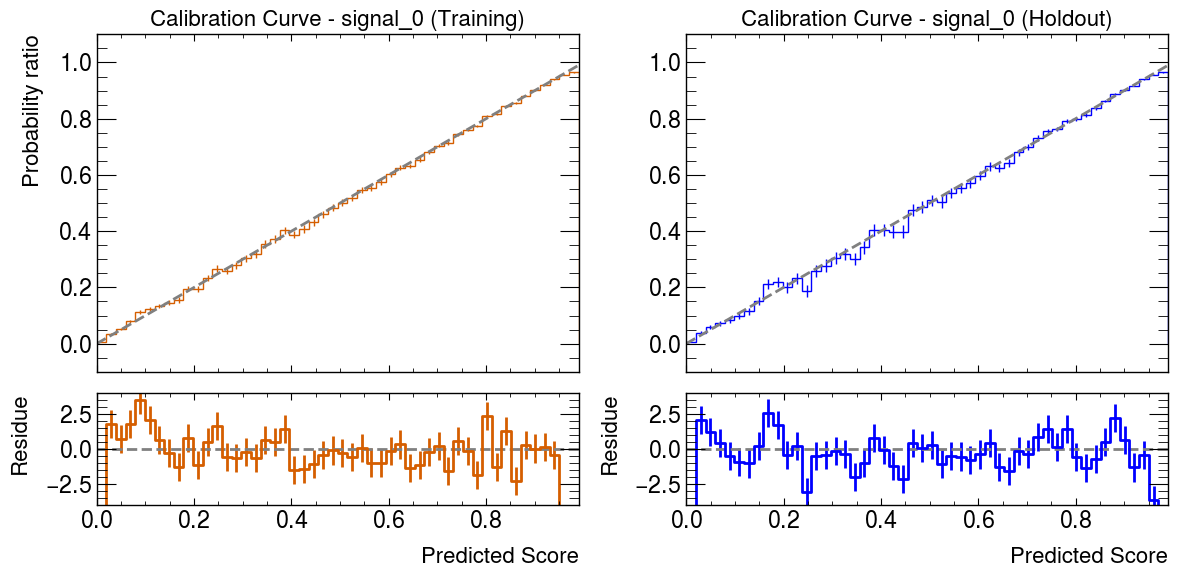

<Figure size 800x600 with 0 Axes>

In [13]:
trainer.make_calib_plots(observable='score', nbins=50, ensemble_index=0)